--- 1. Перші 5 рядків набору даних ---
         date   day  aircraft  helicopter   tank    APC  field artillery  \
0  2026-09-12  1662       442         356  12342  25322            49601   
1  2026-09-11  1661       441         356  12341  25312            49516   
2  2026-09-10  1660       441         356  12339  25305            49452   
3  2026-09-09  1659       441         355  12338  25290            49383   
4  2026-09-08  1658       441         355  12332  25285            49341   

    MRL  military auto  fuel tank   drone  naval ship  anti-aircraft warfare  \
0  2115            NaN        NaN  512175          35                   1633   
1  2109            NaN        NaN  510130          35                   1622   
2  2107            NaN        NaN  508205          35                   1618   
3  2105            NaN        NaN  506188          35                   1613   
4  2104            NaN        NaN  504309          35                   1612   

   special equipment  m

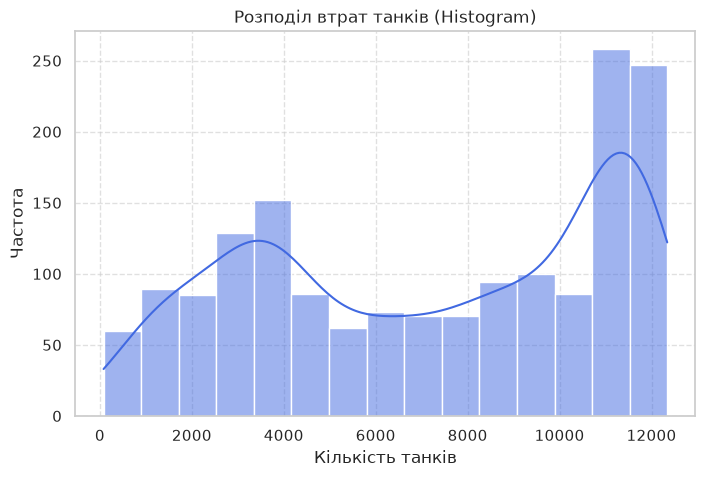

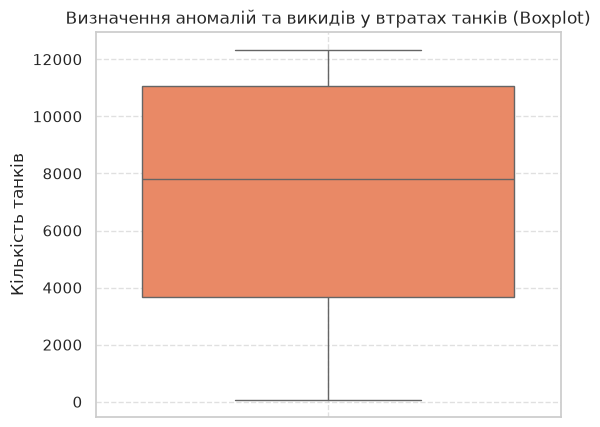

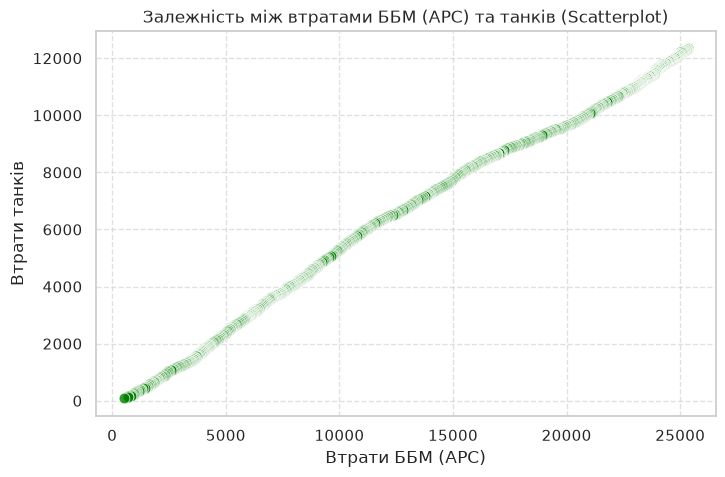

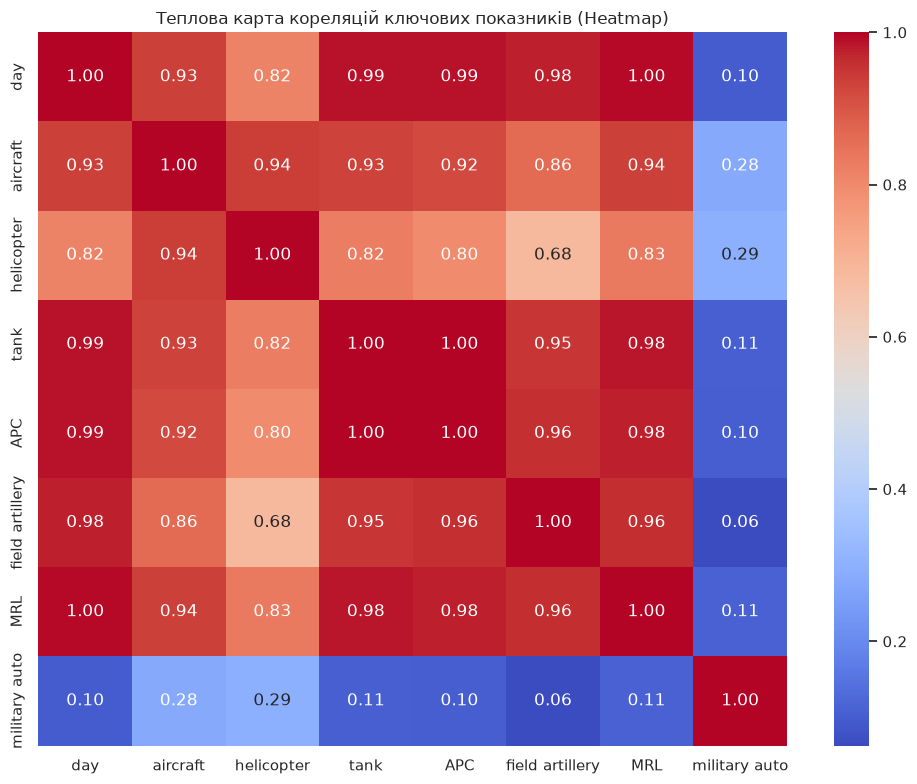


=== РЕЗУЛЬТАТИ ОЦІНКИ МОДЕЛІ ===
R² Score (Коефіцієнт детермінації): 0.9964
MAE (Середня абсолютна помилка): 182.09
RMSE (Корінь із середньоквадратичної помилки): 230.75


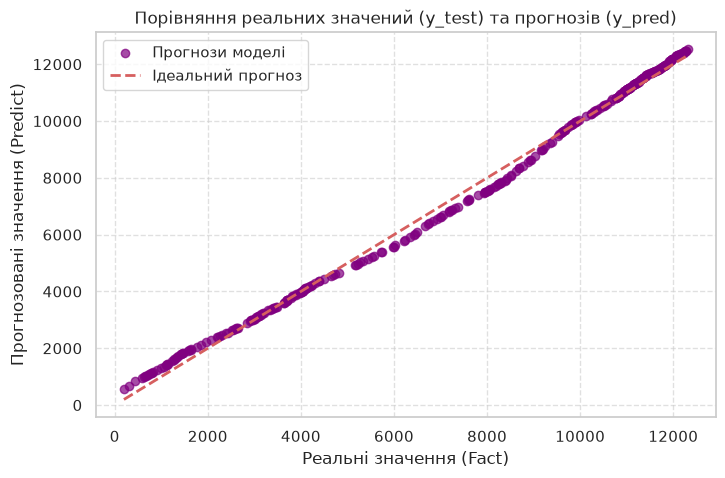

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# ЕТАП 1: ЗАВАНТАЖЕННЯ ТА ПОПЕРЕДНІЙ ПЕРЕГЛЯД
# ==========================================
file_path = r"D:\Kozhan\Практичні роботи\Thema_3\practike_3_5\archive\russia_losses_equipment.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Файл не знайдено за шляхом: {file_path}")

df = pd.read_csv(file_path)

print("--- 1. Перші 5 рядків набору даних ---")
print(df.head())

print("\n--- Інформація про набір даних (df.info()) ---")
print(df.info())

# ==========================================
# ЕТАП 2: ОЧИЩЕННЯ ДАНИХ
# ==========================================
print("\n--- 2. Перевірка на пропущені значення ---")
print(df.isnull().sum())

# Заповнення пропусків: для числових — медіаною, для категоріальних — 'Unknown'
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
for col in non_numeric_cols:
    df[col] = df[col].fillna("Unknown")

# Видалення дублікатів
df.drop_duplicates(inplace=True)

# Перетворення дати
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

# ==========================================
# ЕТАП 3: ТРАНСФОРМАЦІЯ ДАНИХ
# ==========================================
# 1. Нормалізація кількісних змінних (MinMaxScaler)
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\n--- Перші рядки після нормалізації числових змінних ---")
print(df_scaled[numeric_cols].head())

# 2. One-Hot Encoding для категоріальних змінних
if "greatest losses direction" in df.columns:
    df_transformed = pd.get_dummies(
        df, columns=["greatest losses direction"], prefix="direction"
    )
else:
    df_transformed = df.copy()

# ==========================================
# ЕТАП 4: ДЕКОМПОЗИЦІЯ ТА КОРЕЛЯЦІЙНИЙ АНАЛІЗ
# ==========================================
# Вибір фіч та цільової змінної для регресії
features = ["day", "APC"]
target = "tank"

X = df[features]
y = df[target]

# Поділ на навчальну (80%) та тестову (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(
    f"\n--- Декомпозиція вибірки: Навчальна ({len(X_train)} рядків), Тестова ({len(X_test)} рядків) ---"
)

# Кореляційна матриця
correlation_matrix = df[numeric_cols].corr()
print("\n--- Кореляційна матриця для змінної 'tank' ---")
print(correlation_matrix[target].sort_values(ascending=False))

# ==========================================
# ЕТАП 5: ОПИСОВА СТАТИСТИКА ТА ВІЗУАЛІЗАЦІЯ
# ==========================================
print("\n--- Описова статистика (df.describe()) ---")
print(df.describe())

# ВІЗУАЛІЗАЦІЯ 1: Гістограма розподілу
plt.figure(figsize=(8, 5))
sns.histplot(df["tank"], bins=15, kde=True, color="royalblue")
plt.title("Розподіл втрат танків (Histogram)")
plt.xlabel("Кількість танків")
plt.ylabel("Частота")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()  # Вікно 1

# ВІЗУАЛІЗАЦІЯ 2: Коробкова діаграма (Визначення викидів)
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["tank"], color="coral")
plt.title("Визначення аномалій та викидів у втратах танків (Boxplot)")
plt.ylabel("Кількість танків")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()  # Вікно 2

# ВІЗУАЛІЗАЦІЯ 3: Діаграма розсіювання (Scatterplot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["APC"], y=df["tank"], color="green", s=60, alpha=0.8)
plt.title("Залежність між втратами ББМ (APC) та танків (Scatterplot)")
plt.xlabel("Втрати ББМ (APC)")
plt.ylabel("Втрати танків")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()  # Вікно 3

# ВІЗУАЛІЗАЦІЯ 4: Теплова карта кореляції (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix.iloc[:8, :8], annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Теплова карта кореляцій ключових показників (Heatmap)")
plt.tight_layout()
plt.show()  # Вікно 4

# ==========================================
# ЕТАП 6: ПОБУДОВА ТА ОЦІНКА МОДЕЛІ
# ==========================================
model = LinearRegression()
model.fit(X_train, y_train)

# Прогнозування на тестовій вибірці
y_pred = model.predict(X_test)

# Обчислення метрик якості
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== РЕЗУЛЬТАТИ ОЦІНКИ МОДЕЛІ ===")
print(f"R² Score (Коефіцієнт детермінації): {r2:.4f}")
print(f"MAE (Середня абсолютна помилка): {mae:.2f}")
print(f"RMSE (Корінь із середньоквадратичної помилки): {rmse:.2f}")

# ВІЗУАЛІЗАЦІЯ 5: Графік реальних значень проти прогнозованих
plt.figure(figsize=(8, 5))
plt.scatter(
    y_test, y_pred, color="purple", alpha=0.7, label="Прогнози моделі"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ідеальний прогноз",
)
plt.title("Порівняння реальних значений (y_test) та прогнозів (y_pred)")
plt.xlabel("Реальні значення (Fact)")
plt.ylabel("Прогнозовані значення (Predict)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()  # Вікно 5